In [1]:
# Kepler's Third Law Hw9
# 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# 3
df = pd.read_csv("solar_system.csv")

In [3]:
# 4
print(df.shape)
print(df.head(5))
print(df.tail(5))
print(df.columns)
print(df["Attribute"])

# There are 20 rows and 11 columns

(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

In [4]:
# 5
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)

In [5]:
# 6
# Perihelion: the point in an orbit around the sun that is closest to the sun.
# Aphelion: the point in an orbit around the sun that is farthest from the sun.
# Semi-major axis: half the distance of the longest diameter in an ellipse

In [6]:
# 7
semi_major_axis = (perihelion + aphelion) / 2

In [7]:
# 8
new_row = pd.DataFrame([["Semi-major Axis (10^6 km)", *semi_major_axis]], columns=df.columns)
df = pd.concat([df, new_row], ignore_index=True)

In [8]:
# 9
print(df.shape)
# There are now 21 rows and 11 columns

(21, 11)


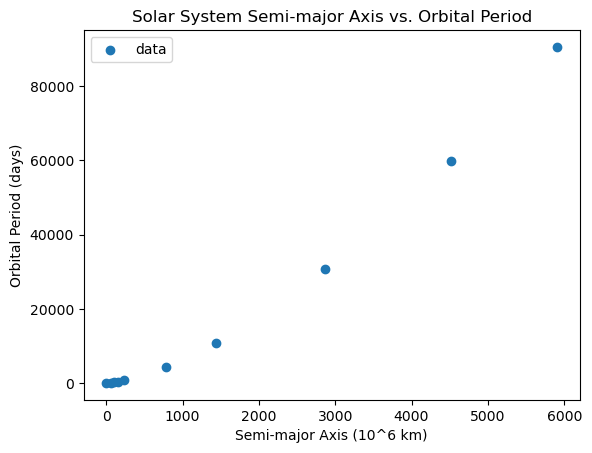

In [9]:
# 10
plt.scatter(semi_major_axis, orbital_period, label="data")
plt.title("Solar System Semi-major Axis vs. Orbital Period")
plt.ylabel("Orbital Period (days)")
plt.xlabel("Semi-major Axis (10^6 km)")
plt.legend()
plt.show()

In [10]:
# 11
def keplers_third_law(a, m):
    return m * a ** 1.5

In [11]:
# 12
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period,)

In [12]:
# 13
m_fit = popt[0]

In [13]:
# 14
print(f"Fit: y = {m_fit:.2f} * a^1.5")

Fit: y = 0.20 * a^1.5


In [14]:
# 15
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2 / dof

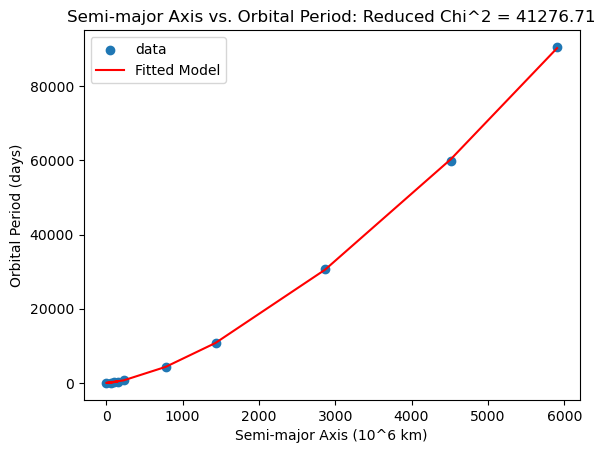

In [15]:
# 16
plt.scatter(semi_major_axis, orbital_period, label = "data")
plt.plot(semi_major_axis, keplers_third_law(semi_major_axis, m_fit), label = "Fitted Model", color = "red")
plt.title(f"Semi-major Axis vs. Orbital Period: Reduced Chi^2 = {chi2_reduced:.2f}")
plt.ylabel("Orbital Period (days)")
plt.xlabel("Semi-major Axis (10^6 km)")
plt.legend()
plt.show()


In [16]:
# 17
df.to_csv("kepler.csv", index=False)